# Simulation for Section 3.3 (monte carlo experiments for linear models)

## Import Required Libraries

In [ ]:
import os
# for cpu
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
import torch
import warnings
from numpy.random import default_rng
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from argparse import Namespace
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.stats import t, norm
from utl import (generate_dgp_data_with_test_sn, Qt_Linear)

from quantes.linear import joint
from arch.covariance.kernel import Andrews
import pickle
print(torch.cuda.is_available())
warnings.filterwarnings('ignore', category=RuntimeWarning)


False


# Functions

## Linear Model

In [ ]:
args = Namespace(
    tau=0.1,
    dof=4,
    scale_norm= 1,
    scale_t= 1,
    val_pct=0.3,
)
def run_sim_ci_dep(m, n = 2048, n_test = 1024, d = 8, n_lag=2, dof = 3.5, rho_x = 0.8, rho_e = 0.9, error_type = 'normal', intercept=False, standardize = False,plot = False, delta = None, eta=None, err_scale = args.scale_norm):
    n_indep = d-n_lag
    X_all, Y_all, Qt, ES, _, beta, *_ = generate_dgp_data_with_test_sn(n, n_test, d=d, tau = args.tau, err_dist=error_type, df = dof, rho_x = rho_x, rho_e = rho_e,
                                                                            delta = delta, eta = eta, n_lag = n_lag,
                                                                    n_indep = n_indep,err_scale=err_scale, seed=m)
    X = X_all[:n, :]
    Y = Y_all[:n]
    X_test = X_all[-n_test:, :]
    Y_test = Y_all[-n_test:]
    testes = ES[-n_test:]
    result = l_fix(n, d, X, Y, X_test, Y_test, testes, beta, intercept, standardize, plot)
    return result
    
def l_fix(n, d, X, Y, X_test, Y_test, testes, beta, intercept = False, standardize = False, plot = False):
    
    n_total = n
    n_val = math.floor(args.val_pct * n_total)
    train_idx = list(range(0, n_total - n_val))
    val_idx = list(range(n_total - n_val, n_total))

    max_values = np.max(np.abs(X[:,intercept:]), axis=0)   # shape: (d,)
    q75 = np.quantile(np.abs(X[:,intercept:]), 0.75, axis=0)

    lower = np.max(q75)
    upper = np.max(max_values)
    # print(lower,upper)

    vsigma = np.append(np.linspace(lower, upper, 10), np.inf)
    # print(vsigma)
    
    bvsigma_q = Qt_Linear(X[train_idx], Y[train_idx], 
                     X[val_idx], Y[val_idx], args.tau,
                     vsigma, standardize = standardize, intercept = intercept,plot = plot)
    ##ours
    X1 = X.copy()
    X1[:,intercept:] = np.clip(X1[:,intercept:], -bvsigma_q['bvsigma_q'], bvsigma_q['bvsigma_q'])
    lm = joint(X1, Y, intercept = intercept)
    qrfit = lm.fit(tau=args.tau, kernel='Laplacian', 
                             standardize=standardize)
    robust = 0.25 * np.mean((np.minimum(qrfit['res'], 0)/args.tau)**4)**(0.25) * (n/d/(np.log(n)**2))**(1/6)
    
    result = lm.twostep(tau=args.tau, loss='Huber', standardize = standardize, ci = True, robust = robust)
    fit_e = X_test[:] @ result['coef_e']
    error = np.mean((testes - fit_e)**2)


    ###ours inference
    res_e = result['res_e']
    res_e = np.clip(res_e, -robust, robust)
    X_tmp = X1.copy()
    X_tmp[:,intercept:] -= np.mean(X_tmp[:,intercept:], axis=0)
    ft = X_tmp * res_e.reshape(-1, 1)
    est = Andrews(ft)
    longrun_cov_est = est.cov.long_run
    cov = X_tmp.T @ X_tmp / n
    cov_inv = np.linalg.inv(cov)
    final_est = cov_inv @ longrun_cov_est @ cov_inv
    sig = np.diag(final_est)
    z_95 = norm.ppf(0.975) 
    quantiles_95 = np.sqrt(sig/n) * z_95 / args.tau  
    lower = result['coef_e'] - quantiles_95
    upper = result['coef_e'] + quantiles_95
    covered = (beta >= lower) & (beta <= upper)

    ##HE inference
    X2 = X.copy()
    lm_HTZ = joint(X2, Y, intercept = intercept)
    result_HTZ = lm_HTZ.twostep(tau=args.tau, loss='Huber', standardize = standardize, ci = True)
    covered_HTZ = (beta >= result_HTZ['ci'][:,0]) & (beta <= result_HTZ['ci'][:,1])
    


    ##FZ
    lm1 = joint(X.copy(), Y, intercept = intercept)
    try:
        result1 = lm1.fz(tau=args.tau, standardize = standardize, refit=False)
        fit_e1 = X_test[:] @ result1['coef_e']
        error1 = np.mean((testes - fit_e1)**2)
    
        #inference
        est_Y_es1 = X @ result1['coef_e']
        est_Y_qr = X @ result1['coef_q']
        Ymax = np.max(Y)
        est_Y_es = est_Y_es1 - Ymax
        indicate = (Y <= est_Y_qr).astype(float) / args.tau

        psi_e = est_Y_es**(-2) * (indicate * (est_Y_qr - Y) - est_Y_qr + est_Y_es1)
        gt_e  = X * psi_e[:, None]                    
        A_ee  = gt_e.T @ gt_e / n
        
        D_e   = (X / est_Y_es[:, None]**2).T @ X / n 
        Dinv  = np.linalg.inv(D_e)
        VCV_e = Dinv @ A_ee @ Dinv / n
        
        quantiles_95_1 = np.sqrt(np.diag(VCV_e))* z_95
        lower1 = result1['coef_e'] - quantiles_95_1
        upper1 = result1['coef_e'] + quantiles_95_1
        covered1 = (beta >= lower1) & (beta <= upper1)
    except Exception as e:
        # print(e)
        error1 = np.nan
        quantiles_95_1 = np.full(d+1, np.nan)
        covered1 = covered1 = np.full(d+1, np.nan)

    return (error,           # 0
            error1,          # 1
            covered,         # 2
            2*quantiles_95,  # 3
            covered1,        # 4
            2*quantiles_95_1,# 5
            covered_HTZ,     # 6
            result_HTZ['ci'][:,1] - result_HTZ['ci'][:,0], # 7
            )   
    

In [ ]:
def summarize_results(result, label='normal'):
    errors = np.array([r[:2] for r in result])

    print(f"\n===== {label} =====")
    print(f"MSPE [error, error1(FZ)]:")
    print(f"  {np.nanmean(errors, axis=0)}")

    covered_mat  = np.stack([r[2]  for r in result])   # Ours
    ciwidth_mat  = np.stack([r[3]  for r in result])
    covered_HTZ   = np.stack([r[6] for r in result])   # HE
    ciwidth_HTZ   = np.stack([r[7] for r in result])
    covered_fz   = np.stack([r[4]  for r in result])   # FZ
    ciwidth_fz   = np.stack([r[5] for r in result])   # 2*quantiles_95_1

    print(f"\n{'method':<12} {'Coverage(excl.intercept)':>24} {'CI Width':>10}")
    print("-" * 48)
    print(f"{'Ours':<12} {np.nanmean(covered_mat[:,1:]):>24.4f} {np.nanmean(ciwidth_mat[:,1:]):>10.4f}")
    print(f"{'HE':<12} {np.nanmean(covered_HTZ[:,1:]):>24.4f} {np.nanmean(ciwidth_HTZ[:,1:]):>10.4f}")
    print(f"{'FZ':<12} {np.nanmean(covered_fz[:,1:]):>24.4f} {np.nanmean(ciwidth_fz[:,1:]):>10.4f}")

## Simulation with n = 10000, d = 30

In [12]:
cores = 250
M = 500
d = 30
n_lag = int(d/2)
rng = default_rng(0)
delta = rng.choice([-2, 2], size=d+1)
eta = rng.binomial(1, 0.5, size=d+1) * 0.25
eta[:n_lag+1] = 0

result1 = Parallel(n_jobs=cores)(
        delayed(run_sim_ci_dep)(m, 10000, 1000, d, n_lag, args.dof, 0.8, 0.9, 'normal', True, True, delta = delta, eta = eta, err_scale = args.scale_norm)
        for m in tqdm(range(M), desc=f'normal')
    )
result2 = Parallel(n_jobs=cores)(
    delayed(run_sim_ci_dep)(m, 10000, 1000, d, n_lag, args.dof, 0.8, 0.9, 't', True, True, delta = delta, eta = eta, err_scale = args.scale_t)
    for m in tqdm(range(M), desc=f't')
)

normal:   0%|          | 0/500 [00:00<?, ?it/s]

t:   0%|          | 0/500 [00:00<?, ?it/s]

In [13]:
summarize_results(result1, label=f'Normal')
summarize_results(result2, label=f't')


===== Normal =====
平均误差指标 [error, error1(FZ)]:
  [0.2323886  0.27963892]

方法           Coverage(excl.intercept)   CI Width
------------------------------------------------
Ours                           0.9305     0.4351
HE                             0.7857     0.3919
FZ                             0.8289     0.5226

===== t =====
平均误差指标 [error, error1(FZ)]:
  [0.33629491 0.432113  ]

方法           Coverage(excl.intercept)   CI Width
------------------------------------------------
Ours                           0.9365     0.5136
HE                             0.7888     0.4670
FZ                             0.8309     0.6187


In [33]:
def plot_boxplot(result, type = 'normal_30'):
    """
    Draw box plots for FZ and LES-H based on the results.
    """
    df = pd.DataFrame(
        [[r[1], r[0]] for r in result],
        columns=["FZ", "LES-H"]
    )

    df = (
        df.replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0)
    )
    if df.empty:
        raise ValueError("There is no valid data available for plotting in the result.")

    Q1 = np.percentile(df, 25, axis=0)
    Q3 = np.percentile(df, 75, axis=0)
    IQR = Q3 - Q1
    lower_bound = Q1 - 2 * IQR
    upper_bound = Q3 + 2 * IQR
    ym = np.ceil(np.max(upper_bound) * 10) / 10

    sns.set_style("darkgrid")
    fig, ax = plt.subplots(1, 1)

    boxplot = ax.boxplot(
        df,
        widths=0.3,
        patch_artist=True,
        flierprops={
            "marker": "o",
            "markersize": 1
        }
    )

    colors = ["lightcoral", "lightskyblue"]
    for patch, color in zip(boxplot["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_linewidth(0.5)

    for median in boxplot["medians"]:
        median.set(
            color="black",
            linewidth=1
        )

    positions = np.arange(1, len(df.columns) + 1)
    ax.set_xticks(positions)
    ax.set_xticklabels(df.columns)

    # ax.set_ylim(0, ym)

    plt.savefig(
        f"./res_linear/boxplot_linear_{type}.pdf",
        bbox_inches="tight",
        format="pdf"
    )
    plt.show()
    plt.close(fig)

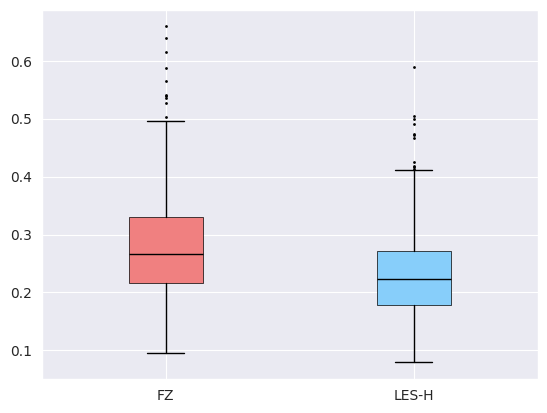

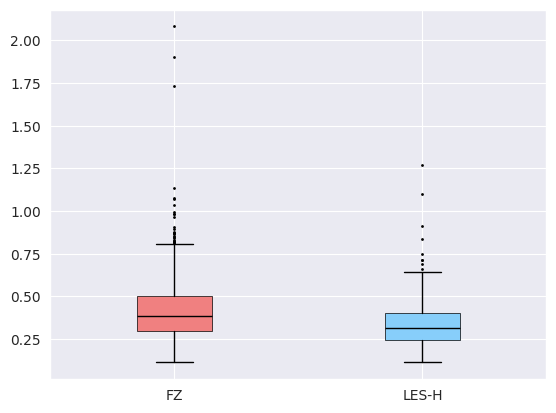

In [34]:
plot_boxplot(result1, 'normal_30')
plot_boxplot(result2, 't_30')

## Simulation with n = 8000, d = 20

In [28]:
cores = 250
M = 500
args.dof=4
d = 20
n_lag = int(d/2)
rng = default_rng(0)
delta = rng.choice([-2, 2], size=d+1)
eta = rng.binomial(1, 0.5, size=d+1) * 0.25
eta[:n_lag+1] = 0

result3 = Parallel(n_jobs=cores)(
        delayed(run_sim_ci_dep)(m, 8000, 1000, d, n_lag, args.dof, 0.8, 0.9, 'normal', True, True, delta = delta, eta = eta, err_scale = args.scale_norm)
        for m in tqdm(range(M), desc=f'normal')
    )
result4 = Parallel(n_jobs=cores)(
    delayed(run_sim_ci_dep)(m,  8000, 1000, d, n_lag, args.dof, 0.8, 0.9, 't', True, True, delta = delta, eta = eta, err_scale = args.scale_t)
    for m in tqdm(range(M), desc=f't')
)

normal:   0%|          | 0/500 [00:00<?, ?it/s]

t:   0%|          | 0/500 [00:00<?, ?it/s]

In [29]:
summarize_results(result3, label=f'Normal')
summarize_results(result4, label=f't')


===== Normal =====
平均误差指标 [error, error1(FZ)]:
  [0.27535967 0.31816315]

方法           Coverage(excl.intercept)   CI Width
------------------------------------------------
Ours                           0.9343     0.5587
HE                             0.7830     0.5003
FZ                             0.8200     0.6210

===== t =====
平均误差指标 [error, error1(FZ)]:
  [0.38550555 0.46179122]

方法           Coverage(excl.intercept)   CI Width
------------------------------------------------
Ours                           0.9361     0.6613
HE                             0.7874     0.5965
FZ                             0.8233     0.7501


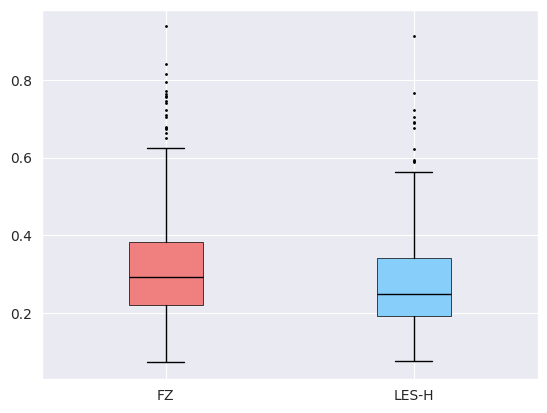

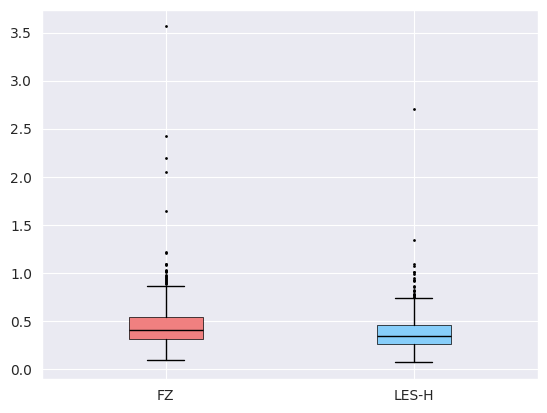

In [35]:
plot_boxplot(result3, 'normal_20')
plot_boxplot(result4, 't_20')

## Inference

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

METHOD_INDEX = {
    "LES-H": {"covered": 2,  "width": 3},
    "HTZ":        {"covered": 6, "width": 7},
    "FZ":        {"covered": 4, "width": 5},
}

sns.set_style("darkgrid")


def _parse_rho_from_key(key):
    """
    key like: 'rho_x=0.8,rho_e=0.3'
    """
    rx = re.search(r"rho_x=([0-9.]+)", key)
    re_ = re.search(r"rho_e=([0-9.]+)", key)

    rho_x = float(rx.group(1)) if rx else np.nan
    rho_e = float(re_.group(1)) if re_ else np.nan
    return rho_x, rho_e


def _stack_result(result, idx):
    """
    Stack the idx-th element of each result into a matrix.
    For example, for coverage: M x (d+1)
    """
    arr = []
    for r in result:
        v = np.asarray(r[idx], dtype=float)
        if v.ndim == 0:
            v = v.reshape(1)
        arr.append(v.ravel())
    return np.vstack(arr)


def collect_inference_summary(all_results, exclude_intercept=True):
    """
    Return a dataframe with columns:
    rho_x, rho_e, dist, method, coverage, ci_width
    """
    rows = []

    for key, res in all_results.items():
        rho_x, rho_e = _parse_rho_from_key(key)

        for dist in ["normal", "t"]:
            if dist not in res:
                continue

            result = res[dist]

            for method, idxs in METHOD_INDEX.items():
                covered = _stack_result(result, idxs["covered"])
                width   = _stack_result(result, idxs["width"])

                if exclude_intercept and covered.shape[1] > 1:
                    covered = covered[:, 1:]
                    width   = width[:, 1:]

                # Each simulation first averages over the dimensions, then averages over M iterations.
                
                covered_rep = np.nanmean(covered, axis=1)
                width_rep   = np.nanmean(width, axis=1)

                rows.append({
                    "rho_x": rho_x,
                    "rho_e": rho_e,
                    "dist": dist,
                    "method": method,
                    "coverage": np.nanmean(covered_rep),
                    "coverage_se": np.nanstd(covered_rep, ddof=1) / np.sqrt(len(covered_rep)),
                    "ci_width": np.nanmean(width_rep),
                    "ci_width_se": np.nanstd(width_rep, ddof=1) / np.sqrt(len(width_rep)),
                    "M": len(result),
                })

    df = pd.DataFrame(rows)
    df = df.sort_values(["rho_x", "dist", "rho_e", "method"]).reset_index(drop=True)
    return df


def summary_inference(all_results, exclude_intercept=True):
    """
    Print a summary table of inference results and return a dataframe.
    """
    df = collect_inference_summary(
        all_results,
        exclude_intercept=exclude_intercept
    )

    print("\n===== Inference Summary Comparison =====")

    for rho_x in sorted(df["rho_x"].dropna().unique()):
        for dist in ["normal", "t"]:
            sub = df[(df["rho_x"] == rho_x) & (df["dist"] == dist)]
            if sub.empty:
                continue

            print(f"\n--- rho_x = {rho_x}, dist = {dist} ---")

            rows = []
            for rho_e in sorted(sub["rho_e"].unique()):
                one = sub[sub["rho_e"] == rho_e]

                row = {"rho_e": rho_e}
                for method in METHOD_INDEX.keys():
                    tmp = one[one["method"] == method]
                    if tmp.empty:
                        continue

                    row[f"{method} Cov"] = tmp["coverage"].iloc[0]
                    row[f"{method} Width"] = tmp["ci_width"].iloc[0]

                rows.append(row)

            out = pd.DataFrame(rows)
            print(out.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    return df

def plot_inference_by_rhoe(df_inf, dist="normal", metric="coverage", rho_x=None):
    """
    metric: 'coverage' or 'ci_width'
    dist: 'normal' or 't'
    rho_x: If there is only one rho_x, you can leave it blank; if there are multiple, it is recommended to specify
    """

    plot_df = df_inf[df_inf["dist"] == dist].copy()

    if rho_x is not None:
        plot_df = plot_df[plot_df["rho_x"] == rho_x]

    if plot_df.empty:
        print("no data to plot, please check dist or rho_x.")
        return

    ylabel = "Empirical coverage" if metric == "coverage" else "Mean interval length"

    plt.figure(figsize=(7, 5))
    ymax = 0
    

    for method in METHOD_INDEX.keys():
        sub = plot_df[plot_df["method"] == method].sort_values("rho_e")
        ymax = max(max(sub[metric]),ymax)
        # print(ymax)
        if sub.empty:
            continue

        plt.plot(
            sub["rho_e"],
            sub[metric],
            marker="o",
            linewidth=2,
            label=method
        )
    plt.ylim(0, ymax+0.1)

    if metric == "coverage":
        plt.axhline(0.95, linestyle="--", linewidth=1)
        plt.ylim(0.7, 1.05)

    plt.xlabel(r"$\varrho$")
    plt.ylabel(ylabel)
    # plt.title(f"{ylabel} vs " + r"$\rho_e$" + f" ({dist})")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(f'./res_linear/res_inference/inference_vs_rho_{metric}_{dist}.pdf', bbox_inches='tight', format="pdf")
    plt.show()
    

In [ ]:
cores = 250
M = 500
args.dof=4
args.scale_t = 1
args.scale_norm = 1
d = 30
n_lag = int(d/2)
rng = default_rng(0)
delta = rng.choice([-2, 2], size=d+1)
eta = rng.binomial(1, 0.5, size=d+1) * 0.25
eta[:n_lag+1] = 0
all_results_dn_try = {}
save_path = "./res_linear/res_inference/all_results_dn.pkl"

for rho_x in [0.8]:
    for rho_e in [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        print(f"\n{'='*50}")
        print(f"n={10000}, d={d}, n_lag={n_lag}, rho_x={rho_x}, rho_e={rho_e}")
        print(f"{'='*50}")

        result1 = Parallel(n_jobs=cores)(
            delayed(run_sim_ci_dep)(m, 10000, 1000, d, n_lag, args.dof, rho_x, rho_e, 'normal', True, True, delta = delta, eta = eta, err_scale = args.scale_norm)
            for m in tqdm(range(M), desc=f'normal')
        )
        result2 = Parallel(n_jobs=cores)(
            delayed(run_sim_ci_dep)(m, 10000, 1000, d, n_lag, args.dof, rho_x, rho_e, 't', True, True, delta = delta, eta = eta, err_scale = args.scale_t)
            for m in tqdm(range(M), desc=f't')
        )

        key = f'rho_x={rho_x},rho_e={rho_e}'
        all_results_dn_try[key] = {'normal': result1, 't': result2}
        summarize_results(result1)
        summarize_results(result2)

In [ ]:
# save
# save_path = "./res_linear/res_inference/all_results_dn.pkl"
# with open(save_path, "wb") as f:
#     pickle.dump(all_results_dn_try, f, protocol=pickle.HIGHEST_PROTOCOL)
# Comment out the code below to rerun
# load
with open("./res_linear/res_inference/all_results_dn.pkl", "rb") as f:
    all_results_dn_try = pickle.load(f)

In [ ]:
df_inf = summary_inference(all_results_dn_try)


===== Inference Summary Comparison =====

--- rho_x = 0.8, dist = normal ---
 rho_e  LES-H Cov  LES-H Width  HTZ Cov  HTZ Width  FZ Cov  FZ Width
0.0000     0.9437       0.3889   0.9472     0.4008  0.9643    0.5293
0.1000     0.9441       0.3901   0.9439     0.4007  0.9623    0.5292
0.2000     0.9457       0.3919   0.9421     0.4006  0.9601    0.5287
0.3000     0.9457       0.3942   0.9359     0.4005  0.9505    0.5291
0.4000     0.9427       0.3969   0.9251     0.4000  0.9439    0.5483
0.5000     0.9398       0.4008   0.9126     0.3996  0.9339    0.5504
0.6000     0.9406       0.4066   0.8943     0.3992  0.9220    0.5429
0.7000     0.9403       0.4132   0.8693     0.3977  0.9061    0.5266
0.8000     0.9364       0.4220   0.8344     0.3956  0.8749    0.6169
0.9000     0.9305       0.4351   0.7857     0.3919  0.8289    0.5263

--- rho_x = 0.8, dist = t ---
 rho_e  LES-H Cov  LES-H Width  HTZ Cov  HTZ Width  FZ Cov  FZ Width
0.0000     0.9479       0.6349   0.9489     0.6575  0.9642    0

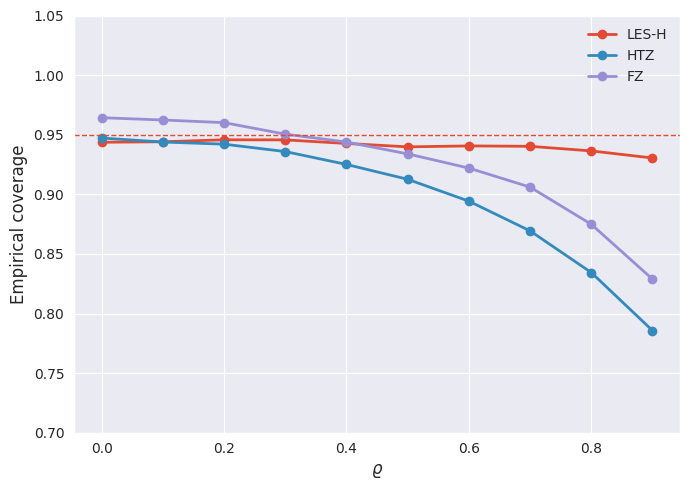

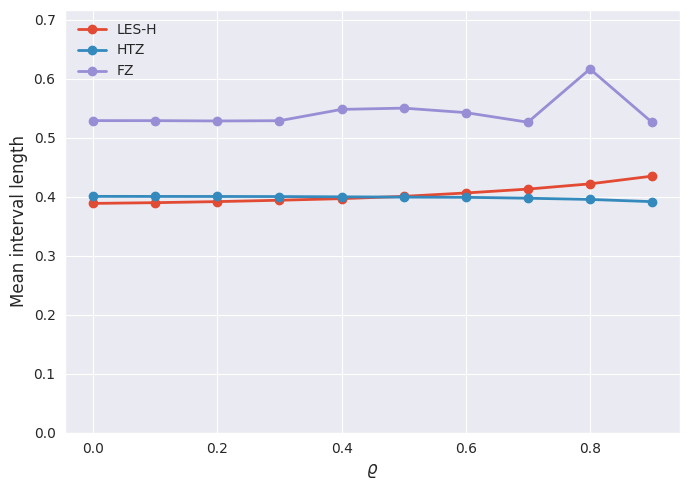

In [ ]:
plot_inference_by_rhoe(df_inf, dist="normal", metric="coverage", rho_x=0.8)
plot_inference_by_rhoe(df_inf, dist="normal", metric="ci_width", rho_x=0.8)

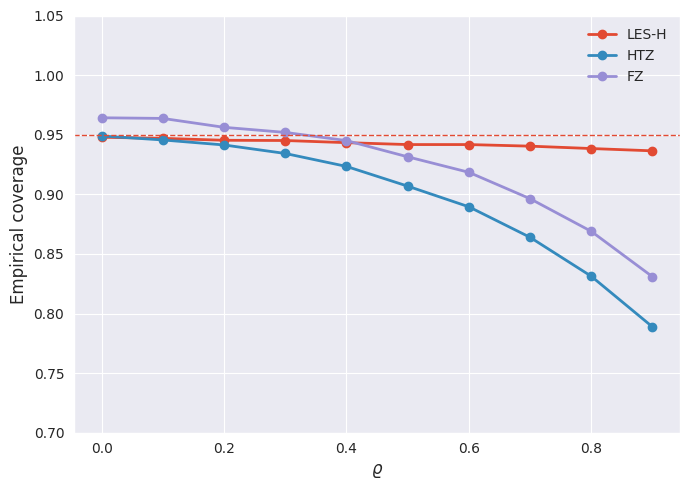

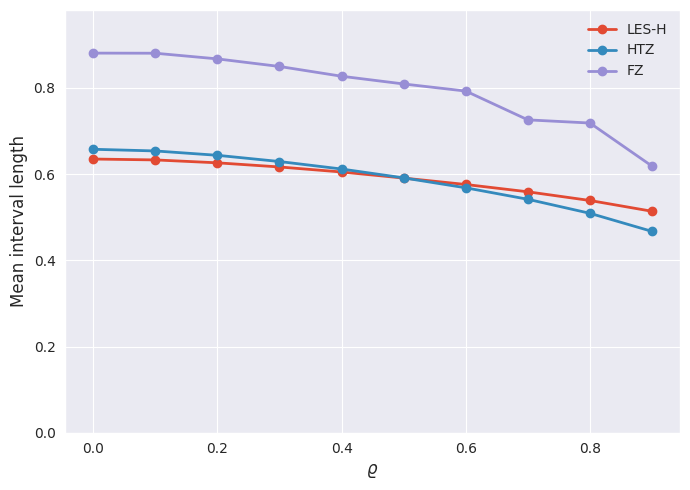

In [ ]:
plot_inference_by_rhoe(df_inf, dist="t", metric="coverage", rho_x=0.8)
plot_inference_by_rhoe(df_inf, dist="t", metric="ci_width", rho_x=0.8)